In [ ]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [24]:
edge_index = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_index.pt')
edge_type = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_type.pt')
edge_weight = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_weight.pt')
features = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\features.pt')
labels_bot = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\labels_bot.pt')
labels_stance = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\labels_stance.pt')

In [35]:
features[1, :].size()

torch.Size([788])

In [16]:
torch.where(labels_bot == 0)[0].shape

torch.Size([7451])

Original edges: 1700108
Self-loops: 205819
Example self-loops:
[[ 1  1]
 [ 3  3]
 [ 6  6]
 [ 8  8]
 [11 11]
 [13 13]
 [16 16]
 [17 17]
 [19 19]
 [21 21]
 [22 22]
 [23 23]
 [26 26]
 [31 31]
 [34 34]
 [38 38]
 [41 41]
 [42 42]
 [44 44]
 [46 46]]
Edges after removing self-loops: 1494289

Graph statistics
----------------
Nodes: 10145
Edges: 902856
Density: 0.017546366331723136

Clustering coefficient
----------------------
Mean: 0.22155102165398044
Median: 0.16363636363636364
Std: 0.1767811097629181
Min: 0.0
Max: 1.0

K-core / degeneracy
-------------------
Degeneracy: 277
Core-number distribution:
1       52
2       55
3       51
4       32
5       44
      ... 
273     11
274      7
275      8
276     11
277    538
Name: count, Length: 267, dtype: int64

Degree statistics
-----------------
Mean degree: 177.9903400689995
Median degree: 114.0
Maximum degree: 5008
Nodes with degree < 20: 532


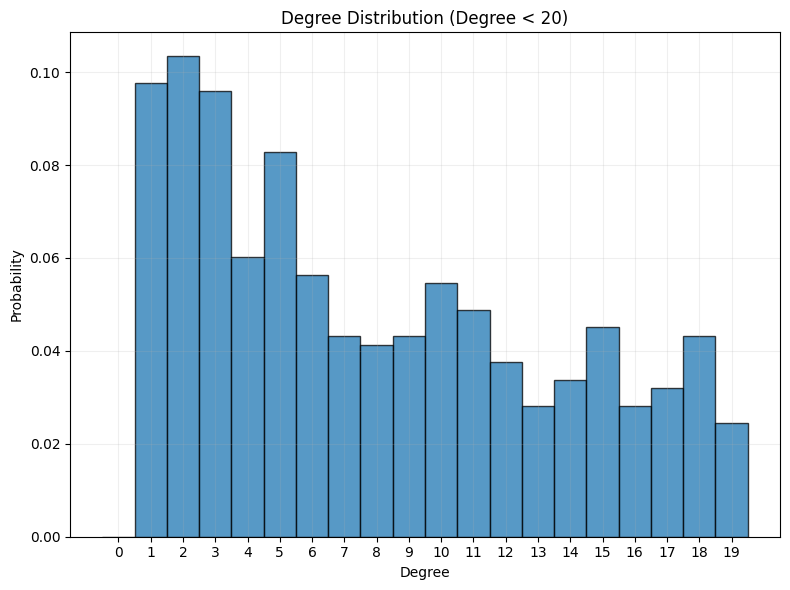

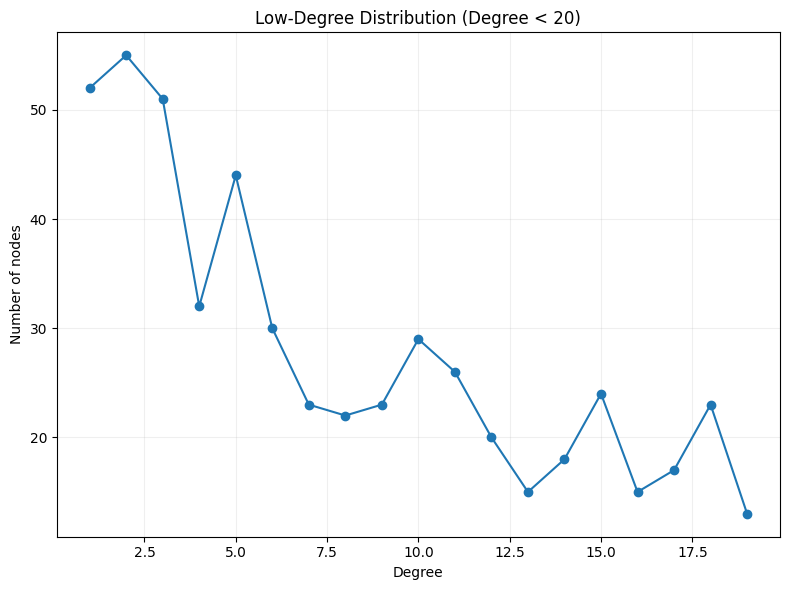

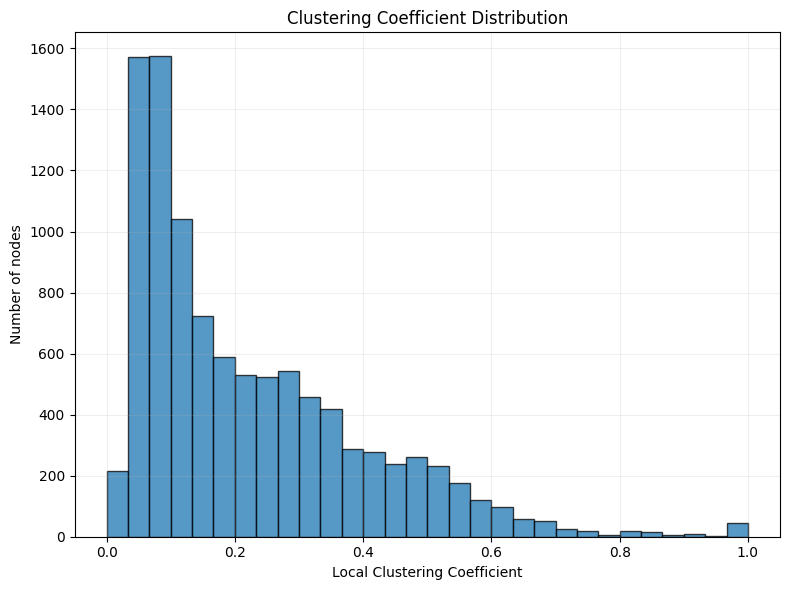

In [ ]:


# ---------------------------------------------------------
# 1. Load edges and labels
# ---------------------------------------------------------

edges = edge_index.cpu().numpy().T
labels = labels_bot.cpu().numpy()

print("Original edges:", len(edges))

# Check self-loops
self_loops = edges[edges[:, 0] == edges[:, 1]]

print("Self-loops:", len(self_loops))

if len(self_loops) > 0:
    print("Example self-loops:")
    print(self_loops[:20])

# Remove self-loops
edges_clean = edges[edges[:, 0] != edges[:, 1]]

print("Edges after removing self-loops:", len(edges_clean))


# ---------------------------------------------------------
# 2. Construct graphs
# ---------------------------------------------------------

G = nx.DiGraph()
G.add_edges_from(edges_clean)

# Add labels to nodes
for i, label in enumerate(labels):
    if G.has_node(i):
        G.nodes[i]["label"] = int(label)

# Undirected version for clustering / k-core / degree
UG = G.to_undirected()

print("\nGraph statistics")
print("----------------")
print("Nodes:", UG.number_of_nodes())
print("Edges:", UG.number_of_edges())
print("Density:", nx.density(UG))


# ---------------------------------------------------------
# 3. Clustering coefficient
# ---------------------------------------------------------

clustering = nx.clustering(UG)

clustering_values = np.array(list(clustering.values()))

print("\nClustering coefficient")
print("----------------------")
print("Mean:", clustering_values.mean())
print("Median:", np.median(clustering_values))
print("Std:", clustering_values.std())
print("Min:", clustering_values.min())
print("Max:", clustering_values.max())


# ---------------------------------------------------------
# 4. Degeneracy / k-core structure
# ---------------------------------------------------------

core_numbers = nx.core_number(UG)

degeneracy = max(core_numbers.values())

print("\nK-core / degeneracy")
print("-------------------")
print("Degeneracy:", degeneracy)

print("Core-number distribution:")
print(pd.Series(core_numbers).value_counts().sort_index())


# ---------------------------------------------------------
# 5. Degree distribution
# ---------------------------------------------------------

degrees = dict(UG.degree())

degree_values = np.array(list(degrees.values()))

print("\nDegree statistics")
print("-----------------")
print("Mean degree:", degree_values.mean())
print("Median degree:", np.median(degree_values))
print("Maximum degree:", degree_values.max())

# Only degrees < 20, as described by the researchers
low_degree = degree_values[degree_values < 20]

print("Nodes with degree < 20:", len(low_degree))


# ---------------------------------------------------------
# 6. Degree distribution plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

bins = np.arange(0, 21) - 0.5

plt.hist(
    low_degree,
    bins=bins,
    density=True,
    alpha=0.75,
    edgecolor="black"
)

plt.xlabel("Degree")
plt.ylabel("Probability")
plt.title("Degree Distribution (Degree < 20)")
plt.xticks(range(20))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Degree frequency plot
# ---------------------------------------------------------

degree_counts = pd.Series(low_degree).value_counts().sort_index()

plt.figure(figsize=(8, 6))

plt.plot(
    degree_counts.index,
    degree_counts.values,
    marker="o"
)

plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Low-Degree Distribution (Degree < 20)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 8. Clustering coefficient distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(
    clustering_values,
    bins=30,
    alpha=0.75,
    edgecolor="black"
)

plt.xlabel("Local Clustering Coefficient")
plt.ylabel("Number of nodes")
plt.title("Clustering Coefficient Distribution")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [30]:
# ---------------------------------------------------------
# Human vs Bot metrics
# ---------------------------------------------------------

human_nodes = [
    n for n in UG.nodes()
    if UG.nodes[n].get("label") == 0
]

bot_nodes = [
    n for n in UG.nodes()
    if UG.nodes[n].get("label") == 1
]

print("Human nodes:", len(human_nodes))
print("Bot nodes:", len(bot_nodes))


def graph_metrics(G, nodes):
    """
    Calculate metrics on an induced subgraph.
    """

    H = G.subgraph(nodes).copy()

    if H.number_of_nodes() == 0:
        return None

    # Clustering
    clustering = nx.clustering(H)
    clustering_values = np.array(list(clustering.values()))

    # Degree
    degrees = np.array([
        d for _, d in H.degree()
    ])

    # Degeneracy
    if H.number_of_edges() > 0:
        core_numbers = nx.core_number(H)
        degeneracy = max(core_numbers.values())
    else:
        degeneracy = 0

    return {
        "nodes": H.number_of_nodes(),
        "edges": H.number_of_edges(),
        "density": nx.density(H),
        "mean_clustering": clustering_values.mean(),
        "median_clustering": np.median(clustering_values),
        "mean_degree": degrees.mean(),
        "median_degree": np.median(degrees),
        "max_degree": degrees.max(),
        "degeneracy": degeneracy
    }


human_metrics = graph_metrics(UG, human_nodes)
bot_metrics = graph_metrics(UG, bot_nodes)

print("\nHUMAN NETWORK")
print("=============")

for key, value in human_metrics.items():
    print(f"{key}: {value}")


print("\nBOT NETWORK")
print("===========")

for key, value in bot_metrics.items():
    print(f"{key}: {value}")


Human nodes: 7447
Bot nodes: 2698

HUMAN NETWORK
nodes: 7447
edges: 632922
density: 0.022828417242794555
mean_clustering: 0.23404795574604614
median_clustering: 0.18099231306778477
mean_degree: 169.98039478984825
median_degree: 105.0
max_degree: 3690
degeneracy: 264

BOT NETWORK
nodes: 2698
edges: 43865
density: 0.01205661068650256
mean_clustering: 0.17452612894273467
median_clustering: 0.1343312055176462
mean_degree: 32.5166790214974
median_degree: 25.0
max_degree: 151
degeneracy: 70


Original edges: 1700108
Edges after removing self-loops: 1494289
Number of bot nodes: 2748
Bot-only edges: 44733

Bot-only network
----------------
Bot nodes: 2748
Bot edges: 44066
Self-loops: 0


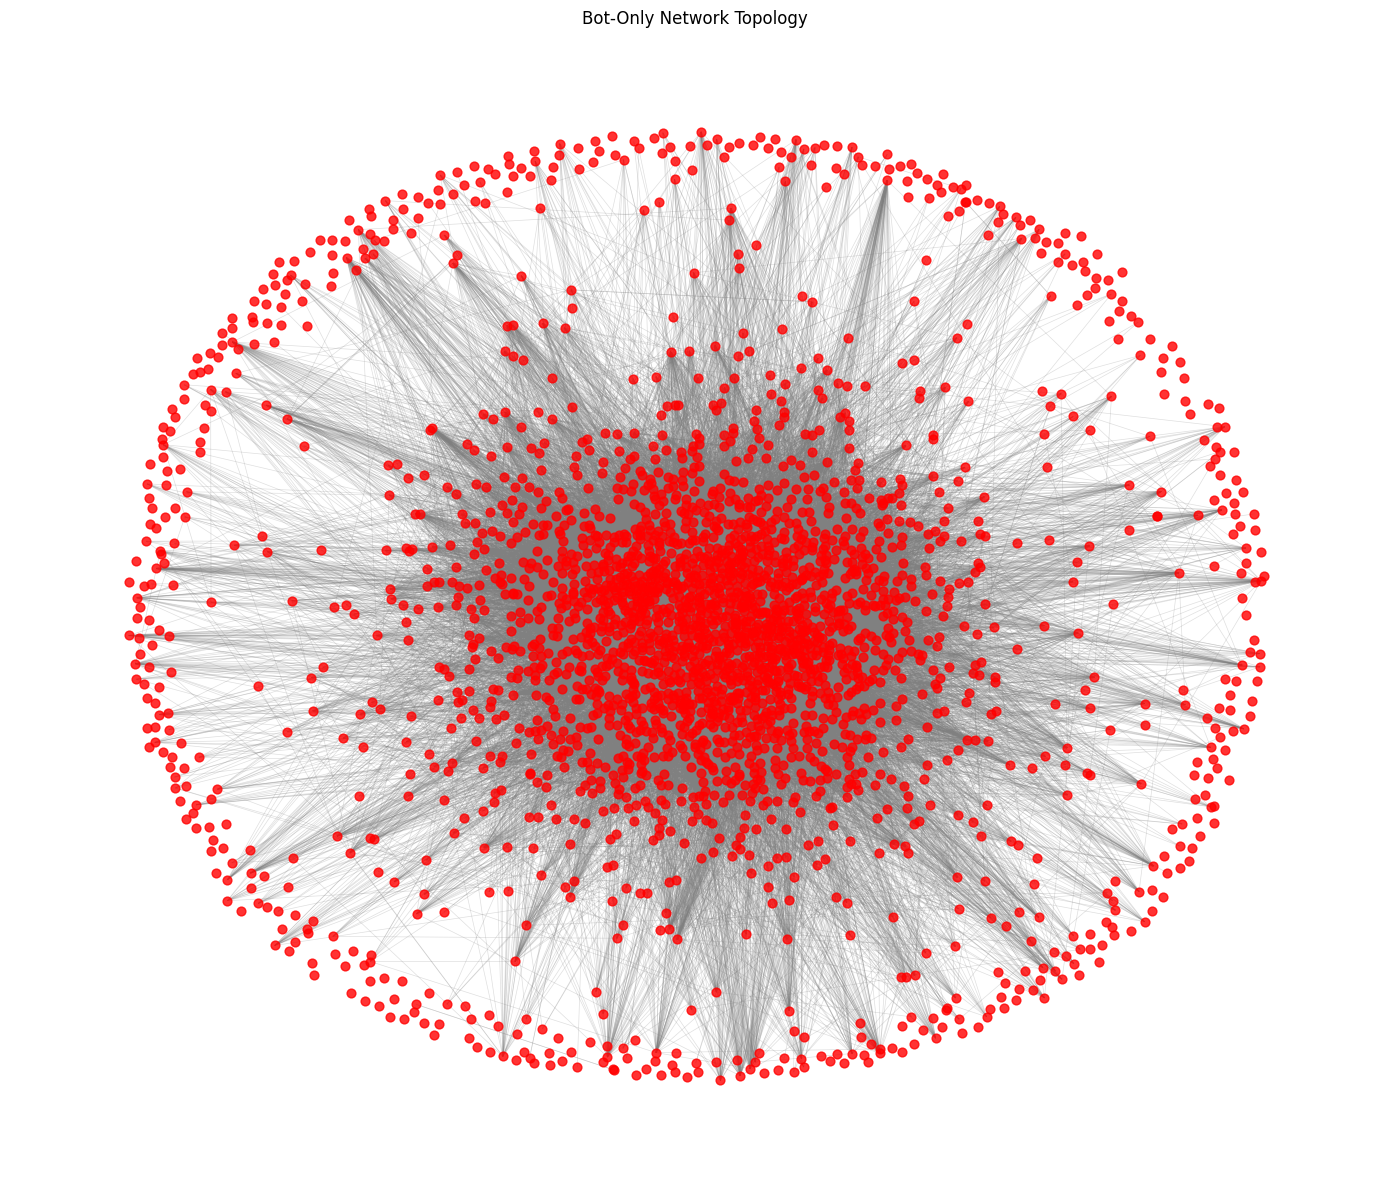

In [36]:
# ---------------------------------------------------------
# 1. Load edges and labels
# ---------------------------------------------------------

edges = edge_index.cpu().numpy().T
labels = labels_bot.cpu().numpy()

print("Original edges:", len(edges))

# ---------------------------------------------------------
# 2. Remove self-loops FIRST
# ---------------------------------------------------------

edges_clean = edges[edges[:, 0] != edges[:, 1]]

print("Edges after removing self-loops:", len(edges_clean))

# ---------------------------------------------------------
# 3. Identify bot nodes
# ---------------------------------------------------------

bot_nodes = np.where(labels == 1)[0]

print("Number of bot nodes:", len(bot_nodes))

bot_node_set = set(bot_nodes)

# ---------------------------------------------------------
# 4. Keep ONLY edges between bots
# ---------------------------------------------------------

bot_edges = np.array([
    [u, v]
    for u, v in edges_clean
    if u in bot_node_set and v in bot_node_set
])

print("Bot-only edges:", len(bot_edges))

# ---------------------------------------------------------
# 5. Construct bot-only graph
# ---------------------------------------------------------

G_bot = nx.DiGraph()

# Add ALL bot nodes, including isolated bots
G_bot.add_nodes_from(bot_nodes)

# Add bot-to-bot edges
G_bot.add_edges_from(bot_edges)

# Safety check: remove any self-loops
G_bot.remove_edges_from(nx.selfloop_edges(G_bot))

print("\nBot-only network")
print("----------------")
print("Bot nodes:", G_bot.number_of_nodes())
print("Bot edges:", G_bot.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G_bot))

# ---------------------------------------------------------
# 6. Plot bot-only network
# ---------------------------------------------------------

plt.figure(figsize=(14, 12))

# Spring layout
pos = nx.spring_layout(
    G_bot,
    seed=42,
    k=0.3,
    iterations=100
)

nx.draw_networkx_nodes(
    G_bot,
    pos,
    node_color="red",
    node_size=40,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_bot,
    pos,
    edge_color="gray",
    alpha=0.25,
    arrows=False,
    width=0.5
)

plt.title("Bot-Only Network Topology")
plt.axis("off")
plt.tight_layout()
plt.show()


Original edges: 1700108
Edges after removing self-loops: 1494289
Bot nodes: 2748
Human nodes: 7451

BOT-ONLY NETWORK
Nodes: 2748
Edges: 44066
Self-loops: 0

HUMAN-ONLY NETWORK
Nodes: 7451
Edges: 844968
Self-loops: 0


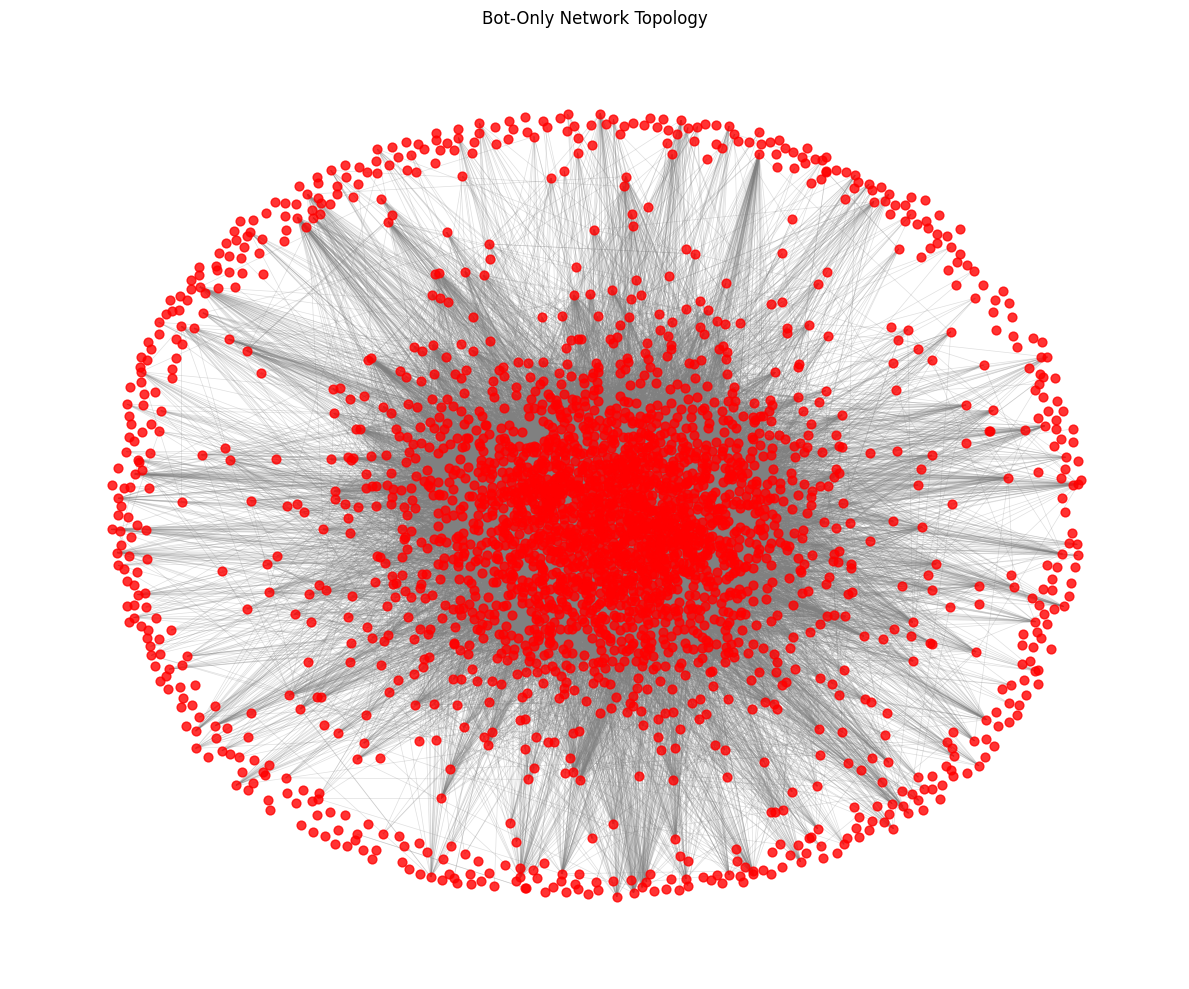

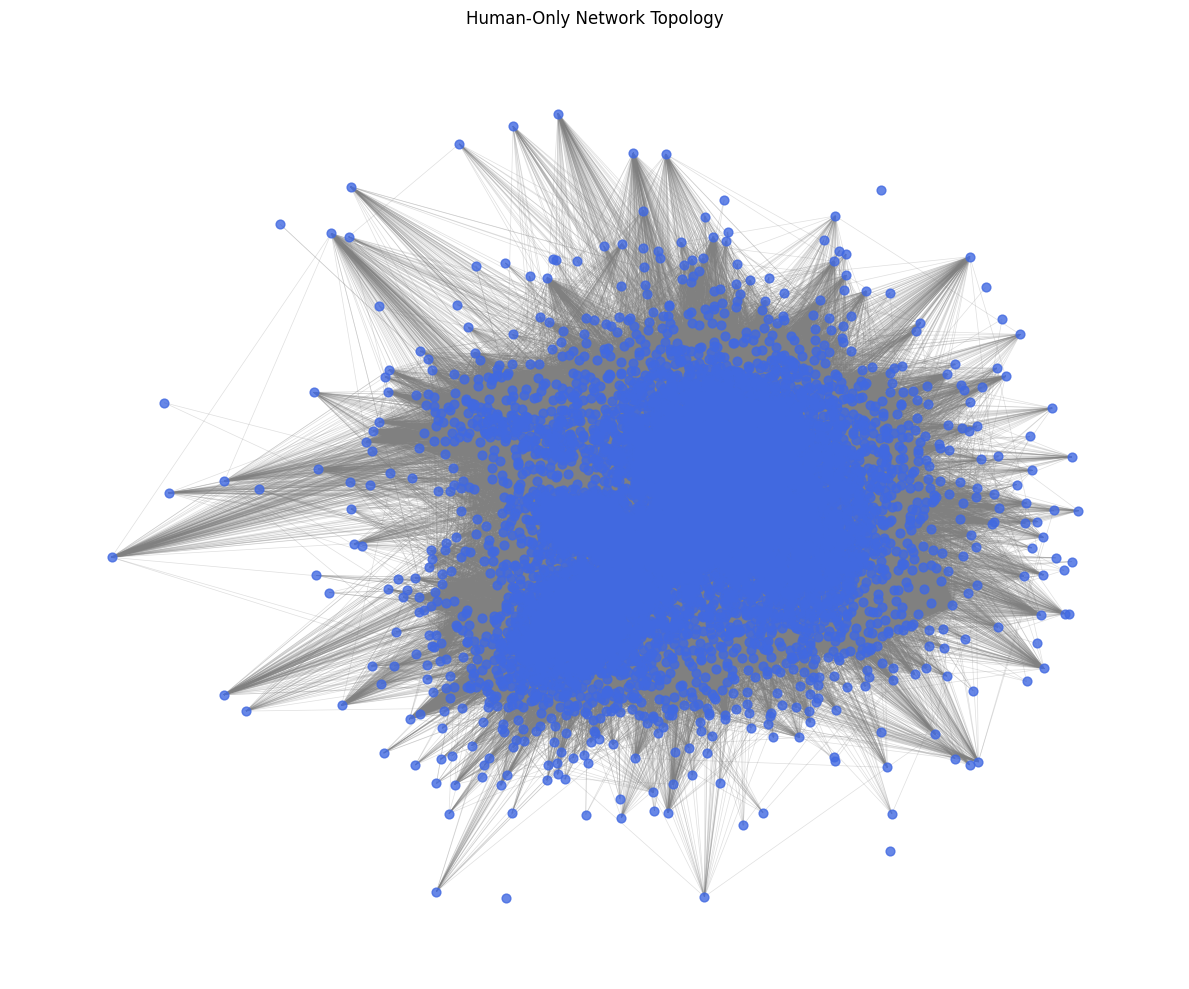

In [37]:
# ---------------------------------------------------------
# 1. Load edges and labels
# ---------------------------------------------------------

edges = edge_index.cpu().numpy().T
labels = labels_bot.cpu().numpy()

print("Original edges:", len(edges))

# ---------------------------------------------------------
# 2. Remove ALL self-loops
# ---------------------------------------------------------

edges_clean = edges[edges[:, 0] != edges[:, 1]]

print("Edges after removing self-loops:", len(edges_clean))

# ---------------------------------------------------------
# 3. Get bot and human nodes
# ---------------------------------------------------------

bot_nodes = np.where(labels == 1)[0]
human_nodes = np.where(labels == 0)[0]

print("Bot nodes:", len(bot_nodes))
print("Human nodes:", len(human_nodes))


# =========================================================
# BOT-ONLY NETWORK
# =========================================================

bot_node_set = set(bot_nodes)

bot_edges = np.array([
    [u, v]
    for u, v in edges_clean
    if u in bot_node_set and v in bot_node_set
])

G_bot = nx.DiGraph()

# Add all bot nodes
G_bot.add_nodes_from(bot_nodes)

# Add bot-to-bot edges
if len(bot_edges) > 0:
    G_bot.add_edges_from(bot_edges)

# Safety check
G_bot.remove_edges_from(nx.selfloop_edges(G_bot))


# =========================================================
# HUMAN-ONLY NETWORK
# =========================================================

human_node_set = set(human_nodes)

human_edges = np.array([
    [u, v]
    for u, v in edges_clean
    if u in human_node_set and v in human_node_set
])

G_human = nx.DiGraph()

# Add all human nodes
G_human.add_nodes_from(human_nodes)

# Add human-to-human edges
if len(human_edges) > 0:
    G_human.add_edges_from(human_edges)

# Safety check
G_human.remove_edges_from(nx.selfloop_edges(G_human))


# =========================================================
# PRINT NETWORK STATISTICS
# =========================================================

print("\n==============================")
print("BOT-ONLY NETWORK")
print("==============================")

print("Nodes:", G_bot.number_of_nodes())
print("Edges:", G_bot.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G_bot))


print("\n==============================")
print("HUMAN-ONLY NETWORK")
print("==============================")

print("Nodes:", G_human.number_of_nodes())
print("Edges:", G_human.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G_human))


# =========================================================
# PLOT BOT-ONLY NETWORK
# =========================================================

plt.figure(figsize=(12, 10))

pos_bot = nx.spring_layout(
    G_bot,
    seed=42,
    k=0.3,
    iterations=100
)

nx.draw_networkx_nodes(
    G_bot,
    pos_bot,
    node_color="red",
    node_size=40,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_bot,
    pos_bot,
    edge_color="gray",
    alpha=0.25,
    arrows=False,
    width=0.5
)

plt.title("Bot-Only Network Topology")
plt.axis("off")
plt.tight_layout()
plt.show()


# =========================================================
# PLOT HUMAN-ONLY NETWORK
# =========================================================

plt.figure(figsize=(12, 10))

pos_human = nx.spring_layout(
    G_human,
    seed=42,
    k=0.3,
    iterations=100
)

nx.draw_networkx_nodes(
    G_human,
    pos_human,
    node_color="royalblue",
    node_size=40,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_human,
    pos_human,
    edge_color="gray",
    alpha=0.25,
    arrows=False,
    width=0.5
)

plt.title("Human-Only Network Topology")
plt.axis("off")
plt.tight_layout()
plt.show()


In [38]:
import torch

features = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\features.pt')      # [10199, 788]
labels   = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\labels_bot.pt')   # [10199]  — 0=human, 1=bot
edge_index = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_index.pt') # [2, E]
edge_type  = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_type.pt')  # [E]

print(features.shape)   # confirms 10199 users × 788 features
print(labels.unique())  # should show tensor([0, 1])
print((labels == 0).sum())  # number of human users (~7451)
print((labels == 1).sum())  # number of bot users (~2748)

# Extract human-only node indices
human_mask = (labels == 0)
human_idx  = human_mask.nonzero(as_tuple=True)[0]

# Filter edges to human-human only
src, dst = edge_index
human_set = set(human_idx.tolist())
mask = torch.tensor([s.item() in human_set and d.item() in human_set 
                     for s, d in zip(src, dst)])
human_edge_index = edge_index[:, mask]
human_edge_type  = edge_type[mask]

print(f"Human-human edges: {mask.sum()}")

torch.Size([10199, 788])
tensor([0, 1])
tensor(7451)
tensor(2748)
Human-human edges: 1384923


In [39]:
property_features = features[:, :20]    # account metadata
tweet_embeddings  = features[:, 20:]    # LaBSE tweet embedding (768-dim)

In [40]:
property_features

tensor([[1., 1., 0.,  ..., 1., 0., 0.],
        [1., 1., 0.,  ..., 1., 1., 0.],
        [1., 1., 0.,  ..., 1., 0., 0.],
        ...,
        [1., 1., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 1., 1.]])

In [43]:
import torch
import json
import numpy as np

# 1. Load MGTAB Tensors
edge_index = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_index.pt')
edge_type = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_type.pt')
edge_weight = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\edge_weight.pt')
features = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\features.pt')
labels_bot = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\labels_bot.pt')
labels_stance = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\MGTAB\data\labels_stance.pt')

# Load text features/metadata (ensure you have user profiles & tweet texts mapped by index)
# user_profiles = {node_id: {"bio": "...", "tweets": "..."}}

# 2. Extract Human-Only Edges
human_mask = (labels_bot[edge_index[0]] == 0) & (labels_bot[edge_index[1]] == 0)
human_src = edge_index[0][human_mask]
human_dst = edge_index[1][human_mask]
human_edge_types = edge_type[human_mask]

# 3. Aggregate Interaction Frequencies per Pair
pair_counts = {}
for src, dst, e_type in zip(human_src, human_dst, human_edge_types):
    if src == dst:
        continue  # Skip self-loops
    pair = (int(src), int(dst))
    if pair not in pair_counts:
        pair_counts[pair] = {"count": 0, "types": []}
    pair_counts[pair]["count"] += 1
    pair_counts[pair]["types"].append(int(e_type))


# 4. Assign Egocentric Relationship Levels (1-4)
def assign_rel_level(count):
    if count >= 5:
        return 1
    elif count >= 2:
        return 2
    elif count == 1:
        return 3
    return 4


dataset_pairs = []
for (src, dst), data in pair_counts.items():
    level = assign_rel_level(data["count"])
    dataset_pairs.append(
        {"source_id": src, "target_id": dst, "interaction_count": data["count"], "relationship_level": level}
    )

# 5. Sample 3,000 Human Pairs across diversity of relationship levels
df_pairs = pd.DataFrame(dataset_pairs)
fim_samples = df_pairs.groupby("relationship_level", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 750), random_state=42)
)

print(f"Sampled {len(fim_samples)} human interaction pairs for FIM.")

Sampled 2250 human interaction pairs for FIM.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14312\70180301.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fim_samples = df_pairs.groupby("relationship_level", group_keys=False).apply(


In [42]:
from datasets import load_dataset

# Load your custom dataset
dataset = load_dataset("json", data_files="MGTAB_FIM_Dataset.jsonl")

def format_prompts(batch):
    formatted = []
    for inst, inp, out in zip(batch['instruction'], batch['input'], batch['output']):
        messages = [
            {"role": "system", "content": inst},
            {"role": "user", "content": inp},
            {"role": "assistant", "content": out}
        ]
        formatted.append(messages)
    return {"messages": formatted}

dataset = dataset.map(format_prompts, batched=True)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
from openai import OpenAI

client = OpenAI(api_key="YOUR_DEEPSEEK_API_KEY", base_url="https://api.deepseek.com")

fim_training_data = []

for _, row in fim_samples.iterrows():
    src_profile = user_profiles[row["source_id"]]  # Text bio/tweets
    tgt_profile = user_profiles[row["target_id"]]

    prompt = f"""
    Source User Profile: {src_profile['bio']}
    Source User Tweets: {src_profile['tweets']}
    Target User Profile: {tgt_profile['bio']}
    Ground Truth Relationship Level: {row['relationship_level']} (Level 1=Deep Tie, 2=Active Sympathy, 3=Weak Tie, 4=Sparse)

    Generate a reasoning process (Think) and structured action list (Output) explaining why Source User engages with Target User at this relationship level.

    Follow this exact format:
    Think: <reasoning about persona compatibility, tie strength level {row['relationship_level']}, and engagement frequency>
    Output: <action><type>like/comment/retweet</type><tweet_id>123</tweet_id></action>
    """

    response = client.chat.completions.create(
        model="deepseek-reasoner", messages=[{"role": "user", "content": prompt}]
    )

    # Format into Qwen-3 instruction-tuning format
    fim_training_data.append(
        {
            "instruction": f"Model social interactions based on relationship strength.",
            "input": f"<user_profile>: {src_profile['bio']}\n<tweets>: {src_profile['tweets']}\n<target_profile>: {tgt_profile['bio']}",
            "output": response.choices[0].message.content,
        }
    )

In [ ]:
!pip install peft
!pip install trl
!pip install datasets

In [ ]:
from datasets import load_dataset
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTTrainer

# Load Base Qwen Model
model_id = "Qwen/Qwen2.5-1.5B-Instruct"  # Substitute with Qwen-3 1.7B checkpoint when available
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")

# LoRA Configuration
peft_config = LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj", "v_proj", "k_proj", "o_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

# Load MGTAB Human FIM Dataset
dataset = load_dataset("json", data_files="fim_dataset.json")

# Train Model
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    peft_config=peft_config,
    dataset_text_field="output",
    max_seq_length=1024,
    tokenizer=tokenizer,
)

trainer.train()

In [ ]:
 # [2, Num_Edges][cite: 1]



# Load text features/metadata mapped by node index
# user_profiles = {node_id: {"bio": "...", "age": "...", "location": "...", "education": "..."}}

# 2. Build Human-Only Directed Graph
human_mask = (labels_bot[edge_index[0]] == 0) & (
    labels_bot[edge_index[1]] == 0
)  #[cite: 1, 2]
human_edges = edge_index[:, human_mask].T

G_human = nx.DiGraph()
G_human.add_edges_from(human_edges)

# 3. Sample 3,000 Multi-Hop Paths (3 to 6 hops) via Random Walks
NUM_SAMPLES = 3000
MIN_HOPS = 3  # Requirement: ≥ 3 hops (Source -> Med1 -> Med2 -> Target)
MAX_HOPS = 6  # Small-world diameter limit

gsi_paths = []
human_nodes = list(G_human.nodes())

np.random.seed(42)



NameError: name 'random' is not defined

In [49]:
while len(gsi_paths) < NUM_SAMPLES:
    # Pick a random source node[cite: 2]
    source = np.random.choice(human_nodes)
    target_len = np.random.randint(MIN_HOPS, MAX_HOPS)

    current_node = source
    path = [current_node]

    for _ in range(target_len):
        neighbors = list(G_human.successors(current_node))
        # Avoid dead ends and cycles
        valid_neighbors = [n for n in neighbors if n not in path]

        if not valid_neighbors:
            break
        
        current_node = np.random.choice(valid_neighbors)
        path.append(current_node)

    # Validate path length (must be at least 3 hops / 4 nodes)[cite: 2]
    if len(path) >= MIN_HOPS + 1:
        gsi_paths.append(
            {
                "source_id": path[0],
                "target_id": path[-1],
                "mediator_ids": path[1:-1],
                "full_path": path,
                "hop_count": len(path) - 1,
            }
        )

df_gsi = pd.DataFrame(gsi_paths)
print(f"Extracted {len(df_gsi)} human multi-hop paths for GSI training.")

NetworkXError: The node 2222 is not in the digraph.

In [ ]:
while len(gsi_paths) < NUM_SAMPLES:
    # 1. Cast source to standard Python int to prevent NetworkX KeyError
    source = int(np.random.choice(human_nodes))

    # 2. Ensure selected source node exists in the graph and has outgoing edges
    if not G_human.has_node(source) or G_human.out_degree(source) == 0:
        continue

    target_len = int(np.random.randint(MIN_HOPS, MAX_HOPS))

    current_node = source
    path = [current_node]

    for _ in range(target_len):
        # Safely fetch successors
        if not G_human.has_node(current_node):
            break

        neighbors = list(G_human.successors(current_node))

        # Avoid dead ends and cycles
        valid_neighbors = [
            int(n) for n in neighbors if int(n) not in path
        ]

        if not valid_neighbors:
            break

        # Pick next node and explicitly cast to native int
        current_node = int(np.random.choice(valid_neighbors))
        path.append(current_node)

    # Validate path length (must be at least 3 hops / 4 nodes)[cite: 1]
    if len(path) >= MIN_HOPS + 1:
        gsi_paths.append(
            {
                "source_id": path[0],
                "target_id": path[-1],
                "mediator_ids": path[1:-1],
                "full_path": path,
                "hop_count": len(path) - 1,
            }
        )

df_gsi = pd.DataFrame(gsi_paths)
print(f"Extracted {len(df_gsi)} human multi-hop paths for GSI training.")

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\df_gsi_annotated.csv')
data.head()

,source_id,target_id,mediator_ids,full_path,hop_count,reasoning_trace
0,6256,5819,"[7154, 3816, 3484]","[6256, 7154, 3816, 3484, 5819]",4,6256 → 7154 (Hop: 1)\nStep 2: 7154 → 3816 (Hop...
1,7447,1675,"[1729, 7768, 1904]","[7447, 1729, 7768, 1904, 1675]",4,7447 ↔ 1729\nStep 2: 1729 ↔ 7768\nStep 3: 7768...
2,5751,4806,"[5534, 7360, 960, 7399]","[5751, 5534, 7360, 960, 7399, 4806]",5,5751 → 5534\nStep 2: 5534 → 7360\nStep 4: 7360...
3,6912,207,"[4137, 8692, 9737, 5115]","[6912, 4137, 8692, 9737, 5115, 207]",5,6912 → 4137\nStep 2: 4137 → 8692\nStep 4: 8692...
4,7466,5241,"[8783, 7033, 9327, 1550]","[7466, 8783, 7033, 9327, 1550, 5241]",5,7466 → 8783\nStep 2: 8783 → 7033\nStep 3: 7033...


In [3]:
data.columns

Index(['source_id', 'target_id', 'mediator_ids', 'full_path', 'hop_count',
       'reasoning_trace'],
      dtype='object')

In [6]:
import json

output_filename = "qwen_gsi_dataset.jsonl"
jsonl_records = []

# System prompt defining the GSI graph-reasoning behavior
system_prompt = (
    "You are a graph reasoning agent trained to perform Graph-Augmented Social Inference (GSI). "
    "Your objective is to evaluate multi-hop social connectivity, analyze candidate mediator nodes, "
    "and identify valid traversal paths."
)

for idx, row in data.iterrows():
    # Extract row values
    src = row["source_id"]
    tgt = row["target_id"]
    mediators = row["mediator_ids"]
    path = row["full_path"]
    hops = row["hop_count"]
    trace = row["reasoning_trace"]

    # Construct user query
    user_query = (
        f"Find valid multi-hop paths connecting source node {src} to target node {tgt} "
        f"across exactly {hops} hops using mediator candidates: {mediators}."
    )

    # Wrap reasoning trace in <think> tags for DeepSeek-R1 CoT learning
    assistant_response = f"<think>\n{trace}\n</think>\n\nValid Path Found: {path} (Total: {hops} Hops)."

    # Format into ChatML message structure
    messages_payload = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query},
            {"role": "assistant", "content": assistant_response},
        ]
    }

    jsonl_records.append(messages_payload)

# Write out to .jsonl file
with open(output_filename, "w", encoding="utf-8") as f:
  for record in jsonl_records:
    f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(
    f"Successfully exported {len(jsonl_records)} rows to '{output_filename}'!"
)

Successfully exported 4000 rows to 'qwen_gsi_dataset.jsonl'!


In [8]:
edge_index = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\edge_index.pt')
edge_type = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\edge_type.pt')
edge_weight = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\edge_weight.pt')
features = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\features.pt')
labels_bot = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\labels_bot.pt')
labels_stance = torch.load(r'C:\Users\Administrator\Desktop\Social media mining research\project\data\labels_stance.pt')

In [9]:
import json
import numpy as np
import pandas as pd
import torch

# 1. Filter Human-Only Edges (0 = Human, 1 = Bot)
human_mask = (labels_bot[edge_index[0]] == 0) & (labels_bot[edge_index[1]] == 0)
human_src = edge_index[0][human_mask]
human_dst = edge_index[1][human_mask]
human_edge_types = edge_type[human_mask]
human_weights = edge_weight[human_mask]


# 2. Map Interaction Frequencies / Weights to Relationship Levels (1-4)
def assign_relationship_level(weight):
  if weight >= 0.75:
    return 1  # Level 1: Deep Tie / Support
  elif weight >= 0.50:
    return 2  # Level 2: Active Sympathy
  elif weight >= 0.25:
    return 3  # Level 3: Weak Tie
  return 4  # Level 4: Sparse / One-off


# 3. Sample 4,000 Pairs
num_edges = human_src.size(0)
np.random.seed(42)
sampled_indices = np.random.choice(
    num_edges, size=min(4000, num_edges), replace=False
)

fim_raw_samples = []

for idx in sampled_indices:
  src_id = int(human_src[idx])
  tgt_id = int(human_dst[idx])
  w_val = float(human_weights[idx])
  rel_level = assign_relationship_level(w_val)

  # Extract profile embeddings (first 5 features as user profile summary)
  src_profile = f"Feature_Vector: {features[src_id].tolist()[:5]}"
  tgt_profile = f"Feature_Vector: {features[tgt_id].tolist()[:5]}"
  fake_tweet_id = f"tweet_{tgt_id}_{idx}"

  fim_raw_samples.append({
      "source_id": src_id,
      "target_id": tgt_id,
      "src_profile": src_profile,
      "tgt_profile": tgt_profile,
      "relationship_level": rel_level,
      "tweet_id": fake_tweet_id,
  })

df_fim_raw = pd.DataFrame(fim_raw_samples)
print(f"Prepared {len(df_fim_raw)} FIM samples matching GraphMind format.")

Prepared 4000 FIM samples matching GraphMind format.


In [10]:
df_fim_raw.head()

,source_id,target_id,src_profile,tgt_profile,relationship_level,tweet_id
0,5871,3082,"Feature_Vector: [1.0, 1.0, 0.0, 0.486001580953...","Feature_Vector: [1.0, 0.0, 1.0, 0.591992497444...",1,tweet_3082_1017449
1,2588,6779,"Feature_Vector: [1.0, 0.0, 0.0, 0.367697656154...","Feature_Vector: [1.0, 1.0, 0.0, 0.382042080163...",2,tweet_6779_1292640
2,3136,6117,"Feature_Vector: [1.0, 1.0, 0.0, 0.360033303499...","Feature_Vector: [1.0, 1.0, 0.0, 0.376761972904...",1,tweet_6117_402858
3,9526,3055,"Feature_Vector: [0.0, 0.0, 0.0, 0.449124962091...","Feature_Vector: [0.0, 0.0, 0.0, 0.427322447299...",1,tweet_3055_630138
4,4469,5172,"Feature_Vector: [0.0, 0.0, 0.0, 0.307280391454...","Feature_Vector: [1.0, 1.0, 0.0, 0.461417764425...",1,tweet_5172_449048


In [13]:
df_fim_raw.to_csv('df_fim_raw.csv', index=False)

In [2]:
import pandas as pd
data_fim = pd.read_csv(r'C:\Users\Administrator\Desktop\Social media mining research\project\src\df_fim_annotated.csv')
data_fim.head()

,source_id,target_id,src_profile,tgt_profile,relationship_level,tweet_id,reasoning_trace
0,5871,3082,"Feature_Vector: [1.0, 1.0, 0.0, 0.486001580953...","Feature_Vector: [1.0, 0.0, 1.0, 0.591992497444...",1,tweet_3082_1017449,Analyze the Feature Vectors\nLooking at both F...
1,2588,6779,"Feature_Vector: [1.0, 0.0, 0.0, 0.367697656154...","Feature_Vector: [1.0, 1.0, 0.0, 0.382042080163...",2,tweet_6779_1292640,Analyze the source and target feature vectors ...
2,3136,6117,"Feature_Vector: [1.0, 1.0, 0.0, 0.360033303499...","Feature_Vector: [1.0, 1.0, 0.0, 0.376761972904...",1,tweet_6117_402858,Analyze the Feature Vectors to identify shared...
3,9526,3055,"Feature_Vector: [0.0, 0.0, 0.0, 0.449124962091...","Feature_Vector: [0.0, 0.0, 0.0, 0.427322447299...",1,tweet_3055_630138,Analyze the Feature Vectors of both profiles.\...
4,4469,5172,"Feature_Vector: [0.0, 0.0, 0.0, 0.307280391454...","Feature_Vector: [1.0, 1.0, 0.0, 0.461417764425...",1,tweet_5172_449048,Analyze the Feature Vectors to identify the ke...
